Basic LangGraph Agent with Two Simple Nodes

In [1]:
from typing import Literal, TypedDict

class USDINRRemit(TypedDict):
    usd_Amount: float
    usd_ReturnTotal: float
    targetCurrency: Literal ["INR", "EUR"]
    inr_Total: float

def calcUSDTotal(state: USDINRRemit) -> USDINRRemit:
    state['usd_ReturnTotal'] = state['usd_Amount'] * 1.04
    return state

def convertINRTotal(state: USDINRRemit) -> USDINRRemit:
    state['inr_Total'] = state['usd_ReturnTotal'] * 89
    return state

def convertEURTotal(state: USDINRRemit) -> USDINRRemit:
    state['inr_Total'] = state['usd_ReturnTotal'] * 140
    return state

def choose_conversion(state:USDINRRemit) -> str:
    return state['targetCurrency']



Define LangGraph Edges and Nodes

In [2]:
from langgraph.graph import StateGraph, START, END

builder = StateGraph(USDINRRemit)

builder.add_node("calcUSDTotal_Node", calcUSDTotal)
builder.add_node("convertINRTotal_Node", convertINRTotal)
builder.add_node("convertEURTotal_Node", convertEURTotal)

builder.add_edge(START,"calcUSDTotal_Node")
builder.add_conditional_edges("calcUSDTotal_Node", choose_conversion, {
    "INR": "convertINRTotal_Node",
    "EUR": "convertEURTotal_Node"
})
builder.add_edge(["convertEURTotal_Node", "convertINRTotal_Node"], END)

graph = builder.compile()

c:\Users\Arun.Manglick\AppData\Local\Programs\Python\Python314\Lib\site-packages\langchain_core\_api\deprecation.py:26: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1


Display Graph

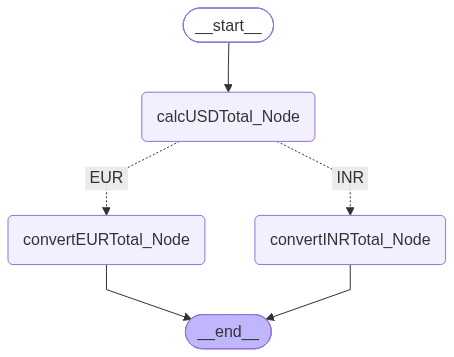

In [3]:
from IPython.display import Image, display
display(graph)

Run Graph

In [6]:
graph.invoke({"usd_Amount": 1000, "targetCurrency": "INR"})

{'usd_Amount': 1000,
 'usd_ReturnTotal': 1040.0,
 'targetCurrency': 'INR',
 'inr_Total': 92560.0}

In [5]:
graph.invoke({"usd_Amount": 1000, "targetCurrency": "EUR"})

{'usd_Amount': 1000,
 'usd_ReturnTotal': 1040.0,
 'targetCurrency': 'EUR',
 'inr_Total': 145600.0}